# Análisis de Churn de Clientes — Sector Telecomunicaciones

**Autora:** Diana Rodríguez Cámara · Graduada en Matemáticas (Universidad de Málaga)

**Objetivo del proyecto:** identificar qué perfiles de cliente tienen mayor probabilidad de darse de baja (*churn*) y qué factores lo explican, para proponer acciones de retención basadas en datos.

**Dataset:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d) — 7.043 clientes de una compañía de telecomunicaciones, con variables demográficas, de contrato y de consumo de servicios.

**Herramientas:** Python · pandas · scipy (inferencia estadística) · scikit-learn (regresión logística) · matplotlib / seaborn

## 1. Contexto de negocio

Retener a un cliente existente cuesta significativamente menos que captar uno nuevo. En telecomunicaciones, donde los ingresos son recurrentes (suscripción mensual), cada cliente que se da de baja representa una pérdida de ingresos futuros previsibles.

Este análisis busca responder tres preguntas:
1. ¿Cuál es la tasa de churn actual y qué variables se asocian a ella?
2. ¿Esa asociación es estadísticamente significativa o podría deberse al azar?
3. ¿Es posible construir un modelo que priorice qué clientes tienen más riesgo de irse, para dirigir campañas de retención de forma eficiente?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sns.set_style("whitegrid")

NAVY = "#1F3864"
CORAL = "#C0574A"
PALETTE = {"No": NAVY, "Yes": CORAL}

## 2. Carga y limpieza de datos

In [2]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")
print(f"Filas: {df.shape[0]}  ·  Columnas: {df.shape[1]}")
df.head()

Filas: 7043  ·  Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# TotalCharges llega como texto y tiene valores en blanco para clientes con tenure=0 (recién llegados)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Valores nulos generados en TotalCharges:", df['TotalCharges'].isna().sum())

df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f"Filas tras limpieza: {df.shape[0]}")

Valores nulos generados en TotalCharges: 11
Filas tras limpieza: 7032


## 3. Análisis exploratorio (EDA)

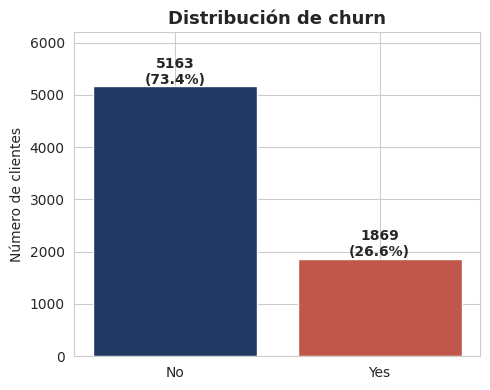


Tasa de churn global: 26.6%


In [4]:
churn_rate = (df['Churn'] == 'Yes').mean()
counts = df['Churn'].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.index, counts.values, color=[PALETTE[c] for c in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f"{v}\n({v/len(df):.1%})", ha='center', fontweight='bold')
ax.set_title("Distribución de churn", fontsize=13, fontweight='bold')
ax.set_ylabel("Número de clientes")
ax.set_ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.savefig("img/01_churn_distribucion.png", dpi=150)
plt.show()

print(f"\nTasa de churn global: {churn_rate:.1%}")

**Lectura:** un 26,6% de los clientes se han dado de baja. Es una base suficientemente grande y equilibrada para un análisis estadístico fiable (no es un evento raro).

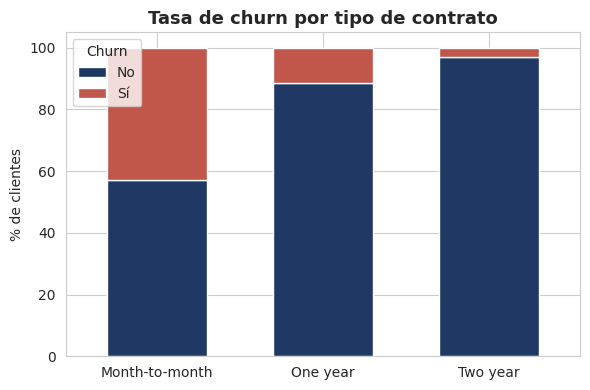

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct = ct.reindex(["Month-to-month", "One year", "Two year"])
ct[['No', 'Yes']].plot(kind='bar', stacked=True, color=[NAVY, CORAL], ax=ax, width=0.6)
ax.set_title("Tasa de churn por tipo de contrato", fontsize=13, fontweight='bold')
ax.set_ylabel("% de clientes")
ax.set_xlabel("")
ax.legend(title="Churn", labels=["No", "Sí"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("img/02_churn_por_contrato.png", dpi=150)
plt.show()

**Lectura:** el contrato mes a mes concentra el grueso de las bajas. Los contratos a uno y dos años prácticamente "blindan" al cliente. Es la variable más visualmente determinante de todo el análisis.

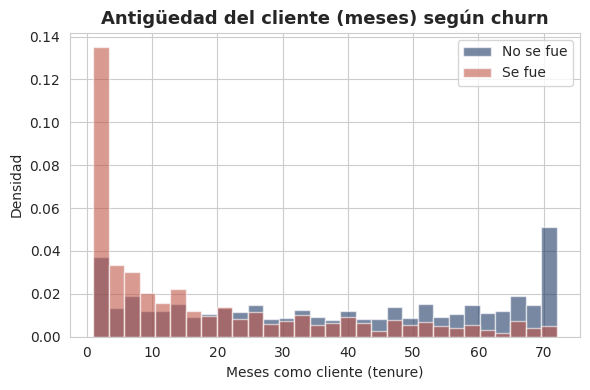

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for churn_val, color, label in [("No", NAVY, "No se fue"), ("Yes", CORAL, "Se fue")]:
    subset = df[df['Churn'] == churn_val]['tenure']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_title("Antigüedad del cliente (meses) según churn", fontsize=13, fontweight='bold')
ax.set_xlabel("Meses como cliente (tenure)")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.savefig("img/03_tenure_por_churn.png", dpi=150)
plt.show()

**Lectura:** los clientes que se dan de baja se concentran en los primeros meses de vida. El riesgo de churn es máximo al principio de la relación y decrece con la antigüedad — algo coherente con la lógica de negocio (el cliente "prueba" el servicio).

/tmp/ipykernel_573/2695407878.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['No se fue', 'Se fue'], patch_artist=True)


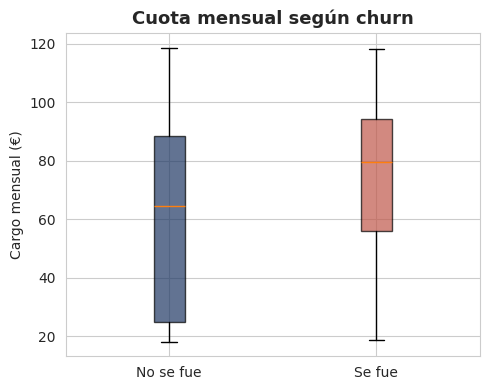

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
data_to_plot = [df[df['Churn'] == c]['MonthlyCharges'] for c in ['No', 'Yes']]
bp = ax.boxplot(data_to_plot, labels=['No se fue', 'Se fue'], patch_artist=True)
for patch, color in zip(bp['boxes'], [NAVY, CORAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Cuota mensual según churn", fontsize=13, fontweight='bold')
ax.set_ylabel("Cargo mensual (€)")
plt.tight_layout()
plt.savefig("img/04_monthly_charges_por_churn.png", dpi=150)
plt.show()

**Lectura:** los clientes que se van pagan de media una cuota mensual más alta. Combinado con el gráfico siguiente, esto apunta a un problema concreto: el servicio de fibra óptica.

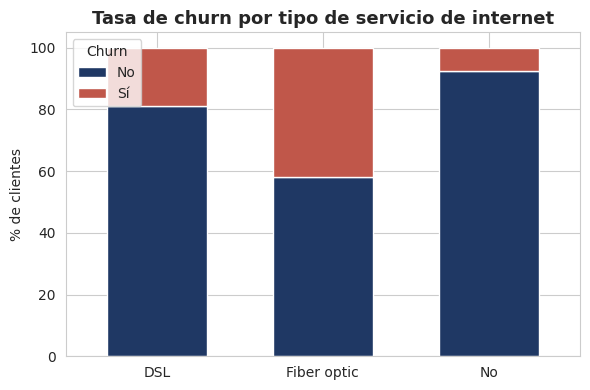

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ct2 = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
ct2[['No', 'Yes']].plot(kind='bar', stacked=True, color=[NAVY, CORAL], ax=ax, width=0.6)
ax.set_title("Tasa de churn por tipo de servicio de internet", fontsize=13, fontweight='bold')
ax.set_ylabel("% de clientes")
ax.set_xlabel("")
ax.legend(title="Churn", labels=["No", "Sí"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("img/05_churn_por_internet.png", dpi=150)
plt.show()

**Lectura:** los clientes de fibra óptica se dan de baja casi al doble de ritmo que los de DSL, pese a ser el servicio más caro. Es una señal de posible insatisfacción con la relación precio-calidad de ese producto — algo a investigar con el equipo de producto.

## 4. ¿Es significativa la relación entre contrato y churn?

Un patrón visual no basta: hay que comprobar si la asociación es estadísticamente significativa o podría deberse al azar. Para dos variables categóricas, el test adecuado es la **prueba de independencia Chi-cuadrado**.

- H₀ (hipótesis nula): el tipo de contrato y el churn son independientes.
- H₁: existe asociación entre ambas variables.

In [9]:
for var in ['Contract', 'PaymentMethod', 'InternetService']:
    contingency = pd.crosstab(df[var], df['Churn'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    print(f"{var:16s} → chi2 = {chi2:9.2f}   p-valor = {p:.2e}   {'✅ significativo' if p < 0.05 else '❌ no significativo'}")

Contract         → chi2 =   1179.55   p-valor = 7.33e-257   ✅ significativo
PaymentMethod    → chi2 =    645.43   p-valor = 1.43e-139   ✅ significativo
InternetService  → chi2 =    728.70   p-valor = 5.83e-159   ✅ significativo


**Lectura:** las tres variables muestran una asociación estadísticamente muy significativa con el churn (p-valor << 0,05). No es casualidad: el tipo de contrato, el método de pago y el tipo de servicio de internet son palancas reales sobre las que se puede actuar.

## 5. Modelo predictivo: regresión logística

Se elige regresión logística en lugar de un modelo de caja negra porque, además de predecir, **permite interpretar el peso de cada variable** sobre la probabilidad de churn — algo esencial si el objetivo final es explicar el resultado a un equipo de negocio, no solo predecirlo.

In [10]:
model_df = df.drop(columns=['customerID']).copy()

cat_cols = model_df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Churn')

le_target = LabelEncoder()
model_df['Churn'] = le_target.fit_transform(model_df['Churn'])  # No=0, Yes=1

model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} clientes  ·  Test: {X_test.shape[0]} clientes")

Entrenamiento: 5274 clientes  ·  Test: 1758 clientes


/tmp/ipykernel_573/1471484536.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include=['object']).columns.tolist()


In [11]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}
for k, v in metrics.items():
    print(f"{k:10s}: {v:.3f}")

Accuracy  : 0.806
Precision : 0.654
Recall    : 0.574
F1-score  : 0.611
ROC-AUC   : 0.840


**Lectura de las métricas:**
- **Accuracy 80,6%** — el modelo acierta 8 de cada 10 clasificaciones.
- **Recall 57,6%** — de cada 10 clientes que realmente se van, el modelo identifica correctamente a casi 6 *antes* de que se vayan.
- **ROC-AUC 0,84** — el modelo distingue muy bien entre clientes de alto y bajo riesgo (0,5 sería azar puro, 1,0 sería perfecto).

Para una campaña de retención, esto significa que en lugar de contactar al 100% de la base de clientes, la empresa puede dirigir el presupuesto al 20-25% con mayor probabilidad de churn y capturar más de la mitad de las bajas reales.

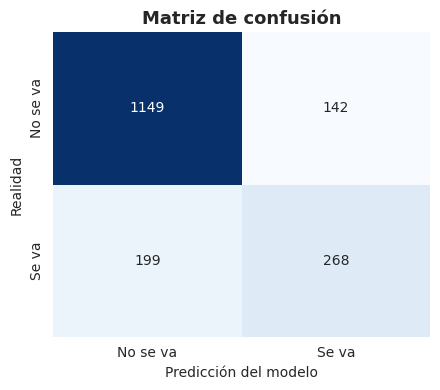

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No se va', 'Se va'], yticklabels=['No se va', 'Se va'], ax=ax)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Realidad")
ax.set_title("Matriz de confusión", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("img/06_matriz_confusion.png", dpi=150)
plt.show()

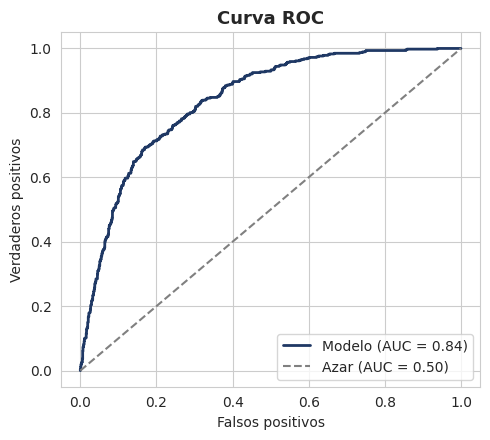

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, color=NAVY, linewidth=2, label=f"Modelo (AUC = {metrics['ROC-AUC']:.2f})")
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Azar (AUC = 0.50)')
ax.set_xlabel("Falsos positivos")
ax.set_ylabel("Verdaderos positivos")
ax.set_title("Curva ROC", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("img/07_curva_roc.png", dpi=150)
plt.show()

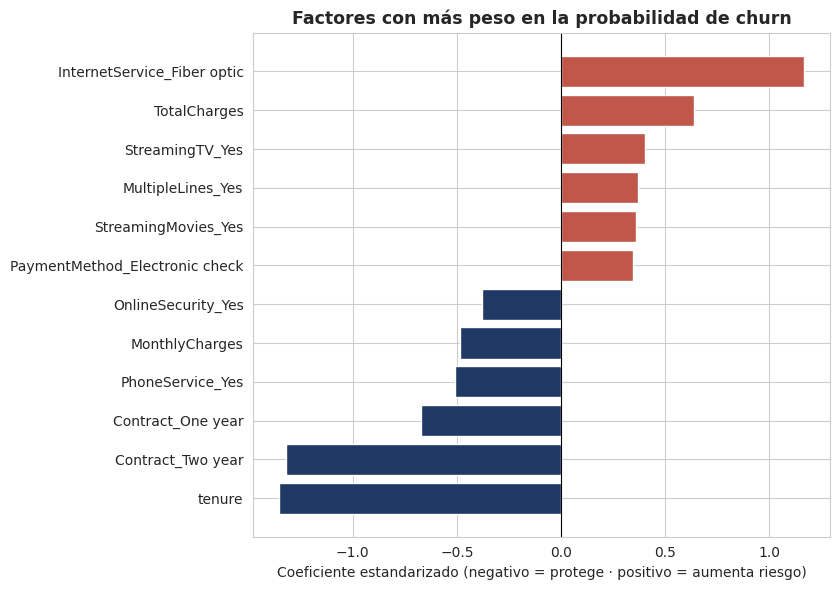

In [14]:
coefs = pd.Series(clf.coef_[0], index=X.columns).sort_values()
top = pd.concat([coefs.head(6), coefs.tail(6)])

fig, ax = plt.subplots(figsize=(8.5, 6))
colors = [CORAL if v > 0 else NAVY for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Factores con más peso en la probabilidad de churn", fontsize=12.5, fontweight='bold')
ax.set_xlabel("Coeficiente estandarizado (negativo = protege · positivo = aumenta riesgo)")
plt.tight_layout()
plt.savefig("img/08_factores_churn.png", dpi=150)
plt.show()

**Lectura:** la antigüedad (`tenure`) es, con diferencia, el factor que más protege frente al churn, seguida de los contratos de uno y dos años — confirma numéricamente lo que ya sugería el análisis exploratorio: fidelizar al cliente en sus primeros meses es la palanca más potente. En el lado opuesto, tener fibra óptica y un gasto total acumulado alto son los factores que más aumentan el riesgo, coherente con la cuota mensual más elevada que pagan estos clientes. El pago mediante cheque electrónico —más manual y menos "pegajoso" que una domiciliación— también se asocia a mayor riesgo.

## 6. Conclusiones y recomendaciones

1. **Priorizar la migración de contratos mes a mes a contratos anuales.** Es la palanca individual más fuerte identificada en todo el análisis — un incentivo (descuento, servicio adicional) para pasar a un contrato de 1-2 años probablemente tenga el mayor retorno sobre la inversión en retención.

2. **Revisar la experiencia del cliente de fibra óptica.** Es el servicio más caro y el que más churn genera pese a ser el "premium" — sugiere un problema de percepción de valor, no solo de precio, que merece una investigación cualitativa (encuestas, soporte).

3. **Fomentar servicios de seguridad y soporte técnico** (`OnlineSecurity`, `TechSupport`): actúan como protectores frente al churn. Incluirlos por defecto o promocionarlos activamente en la fase inicial del cliente podría reducir bajas tempranas.

4. **Incentivar la domiciliación bancaria** frente al pago manual (*electronic check*), que se asocia a mayor riesgo de baja — probablemente por menor fricción de cambio de proveedor.

5. **Usar el modelo como sistema de scoring**, no como sustituto del criterio de negocio: priorizar el contacto proactivo (retención) sobre el 20-25% de clientes con score de riesgo más alto, especialmente en sus primeros meses de vida como cliente.

## 7. Limitaciones y próximos pasos

- El dataset es una foto fija (*snapshot*), no una serie temporal — no captura cambios de comportamiento a lo largo del tiempo.
- Se podría comparar la regresión logística con modelos no lineales (Random Forest, Gradient Boosting) para ver si mejoran el recall a costa de interpretabilidad.
- Añadir el valor del cliente a lo largo de su ciclo de vida (*Customer Lifetime Value*) permitiría priorizar la retención no solo por riesgo, sino por riesgo × valor económico.

---
*Proyecto realizado como parte de mi portfolio de análisis de datos. Código completo disponible en este repositorio.*